Loading datasets...
Training Set Shape: (147613, 51)
Testing Set Shape:  (63267, 51)

Preprocessing, encoding, and scaling categorical features...
Features after encoding and scaling: 64

Treinando K-Means Clustering (k=2)
Fazendo fit no modelo (Aprendizado Não-Supervisionado)...
Mapeando Clusters para Labels baseadas na maioria...
  -> Cluster 0 mapeado para: Normal (0)
  -> Cluster 1 mapeado para: Ataque (1)

Predizendo clusters no conjunto de teste misto...

--- Relatório - Clustering Binário (K-Means) ---
              precision    recall  f1-score   support

  Normal (0)       0.59      0.99      0.74     30351
  Ataque (1)       0.99      0.37      0.54     32916

    accuracy                           0.67     63267
   macro avg       0.79      0.68      0.64     63267
weighted avg       0.80      0.67      0.64     63267



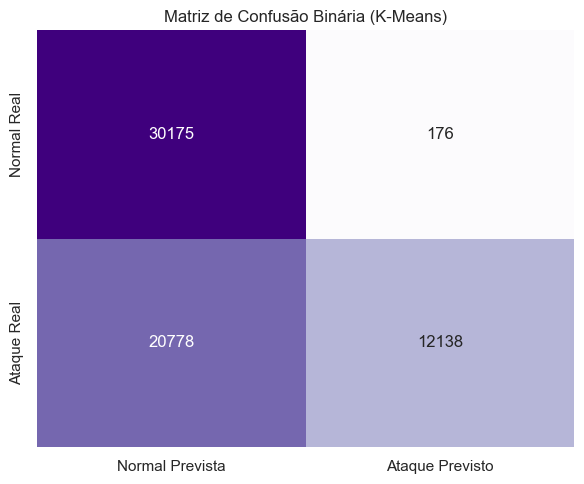


Análise de Distância para os Centroides
Distância Média do Tráfego Normal Real para o Centroide Normal: 4.991
Distância Média dos Ataques Reais para o Centroide Normal:      6.271
(Se o modelo funcionou bem, os ataques devem estar significativamente mais distantes)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Set visualization style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LOAD DATASETS
# ==========================================
print("Loading datasets...")
train_df = pd.read_csv("ubuntu-server_training-set.csv")
test_df = pd.read_csv("ubuntu-server_testing-set.csv")

print(f"Training Set Shape: {train_df.shape}")
print(f"Testing Set Shape:  {test_df.shape}")

# ==========================================
# 2. DATA PREPROCESSING, ENCODING & SCALING
# ==========================================
print("\nPreprocessing, encoding, and scaling categorical features...")

targets = ['label', 'attack_cat']
identities = ['id', 'srcip', 'sport', 'dstip', 'dsport', 'stime', 'ltime', 'ct_state_ttl']
drop_cols = targets + identities

# Separate features (X) and true targets (y)
X_train = train_df.drop(columns=[col for col in drop_cols if col in train_df.columns])
y_train_bin = train_df['label']

X_test = test_df.drop(columns=[col for col in drop_cols if col in test_df.columns])
y_test_bin = test_df['label']

cat_cols = ['proto', 'service', 'state']

# Apply One-Hot Encoding
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols)

# Align Train and Test columns
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# SCALING: Absolute requirement for K-Means (Distance-based algorithm)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f"Features after encoding and scaling: {X_train_scaled.shape[1]}")

# ==========================================
# 3. K-MEANS CLUSTERING (BINARY)
# ==========================================
print("\n" + "="*50)
print("Treinando K-Means Clustering (k=2)")
print("="*50)

# Initialize K-Means with 2 clusters (Normal vs Attack)
kmeans = KMeans(
    n_clusters=2, 
    init='k-means++', # Otimiza a inicialização dos centroides
    n_init=10, 
    random_state=42
)

print("Fazendo fit no modelo (Aprendizado Não-Supervisionado)...")
# Note that we DO NOT pass y_train_bin here. It learns purely from the data shape.
train_clusters = kmeans.fit_predict(X_train_scaled)

# --- CLUSTER TO LABEL MAPPING ---
print("Mapeando Clusters para Labels baseadas na maioria...")
# We must figure out if Cluster 0 is "Normal" or "Attack"
cluster_0_true_labels = y_train_bin[train_clusters == 0]
cluster_1_true_labels = y_train_bin[train_clusters == 1]

# Find the most frequent true label in each cluster
cluster_0_majority = cluster_0_true_labels.mode()[0] if not cluster_0_true_labels.empty else 0
cluster_1_majority = cluster_1_true_labels.mode()[0] if not cluster_1_true_labels.empty else 1

cluster_map = {
    0: cluster_0_majority,
    1: cluster_1_majority
}

print(f"  -> Cluster 0 mapeado para: {'Ataque (1)' if cluster_map[0] == 1 else 'Normal (0)'}")
print(f"  -> Cluster 1 mapeado para: {'Ataque (1)' if cluster_map[1] == 1 else 'Normal (0)'}")

# Warn if K-Means failed to separate the classes properly
if cluster_map[0] == cluster_map[1]:
    print("\n[AVISO] K-Means agrupou a maioria do Tráfego Normal E Ataques no mesmo cluster.")
    print("Isso indica que as classes não são linearmente/esfericamente separáveis com k=2.")

# Predição no conjunto de teste
print("\nPredizendo clusters no conjunto de teste misto...")
test_clusters = kmeans.predict(X_test_scaled)

# Convert predicted raw clusters to our actual 0/1 labels using the map
y_pred_bin = np.vectorize(cluster_map.get)(test_clusters)

# ==========================================
# 4. METRICS & EVALUATION
# ==========================================
print("\n--- Relatório - Clustering Binário (K-Means) ---")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Normal (0)', 'Ataque (1)']))

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Normal Prevista', 'Ataque Previsto'],
            yticklabels=['Normal Real', 'Ataque Real'])
plt.title('Matriz de Confusão Binária (K-Means)')
plt.tight_layout()
plt.show()

# ==========================================
# 5. EXPLAINABILITY: DISTANCE TO CENTROIDS
# ==========================================
print("\n" + "="*50)
print("Análise de Distância para os Centroides")
print("="*50)

# Transform calculates the distance from each point to all cluster centroids
distances = kmeans.transform(X_test_scaled)

# Get the distance to the centroid representing "Normal" traffic
normal_cluster_idx = 0 if cluster_map[0] == 0 else 1
distances_to_normal = distances[:, normal_cluster_idx]

test_df_distances = pd.DataFrame({'Label': y_test_bin, 'Dist_to_Normal': distances_to_normal})

avg_dist_normal = test_df_distances[test_df_distances['Label'] == 0]['Dist_to_Normal'].mean()
avg_dist_attack = test_df_distances[test_df_distances['Label'] == 1]['Dist_to_Normal'].mean()

print(f"Distância Média do Tráfego Normal Real para o Centroide Normal: {avg_dist_normal:.3f}")
print(f"Distância Média dos Ataques Reais para o Centroide Normal:      {avg_dist_attack:.3f}")
print("(Se o modelo funcionou bem, os ataques devem estar significativamente mais distantes)")